In [1]:
import pandas as pd

path = '../../../data/processed/'

df = pd.read_csv(path + 'steam_indie_games_merged_v1.csv')
review_df = pd.read_csv(path + 'eng_review.csv')
histogram_df = pd.read_csv(path + 'steam_indie_review_histogram_preprocessed_lee_v1.csv')

In [9]:
df.dtypes

appid                  int64
name                     str
genres                   str
developers               str
release_date             str
price                float64
positive               int64
negative               int64
owners_higher          int64
owners_lower           int64
developer                str
publisher                str
tags                     str
review_score           int64
review_score_desc        str
total_positive         int64
total_negative         int64
total_reviews          int64
dtype: object

In [10]:
histogram_df.head()

,appid,name,stratum,release_date,hist_start_date,hist_end_date,date,recommendations_up,recommendations_down,data_type,review_date,recommendations_total,days_from_release,release_period,histogram_key
0,402160,Star Command Galaxies,Strategy_high,2024-08-28,2015-09-17,2026-04-05,2026-03-07,0,0,recent,2026-03-07,0,556,D181_plus,402160_2026-03-07_recent
1,402160,Star Command Galaxies,Strategy_high,2024-08-28,2015-09-17,2026-04-05,2026-03-08,0,0,recent,2026-03-08,0,557,D181_plus,402160_2026-03-08_recent
2,402160,Star Command Galaxies,Strategy_high,2024-08-28,2015-09-17,2026-04-05,2026-03-09,0,0,recent,2026-03-09,0,558,D181_plus,402160_2026-03-09_recent
3,402160,Star Command Galaxies,Strategy_high,2024-08-28,2015-09-17,2026-04-05,2026-03-10,0,0,recent,2026-03-10,0,559,D181_plus,402160_2026-03-10_recent
4,402160,Star Command Galaxies,Strategy_high,2024-08-28,2015-09-17,2026-04-05,2026-03-11,0,0,recent,2026-03-11,0,560,D181_plus,402160_2026-03-11_recent


In [2]:
unique_mapping = histogram_df[['appid', 'stratum']].drop_duplicates().reset_index(drop=True)
unique_mapping

,appid,stratum
0,402160,Strategy_high
1,437440,Strategy_mid
2,444690,Strategy_high
3,571740,Sports_high
4,597920,Simulation_mid
...,...,...
195,3389760,Action_mid
196,3443030,Adventure_low
197,3453600,Racing_high
198,3473570,Simulation_low


In [3]:
df = pd.merge(df, unique_mapping, on = 'appid')
df.head()

,appid,name,genres,developers,release_date,price,positive,negative,owners_higher,owners_lower,developer,publisher,tags,review_score,review_score_desc,total_positive,total_negative,total_reviews,stratum
0,402160,Star Command Galaxies,"['Action', 'Adventure', 'Casual', 'Indie', 'RP...",Warballoon,2024-08-28,14.99,213,271,20000,0,Warballoon,Warballoon,"{""2D"": 147, ""RTS"": 228, ""Indie"": 219, ""Space"":...",5,Mixed,152,205,357,Strategy_high
1,437440,Lord of Rigel,"['Indie', 'Simulation', 'Strategy']",Rhombus Studios,2024-08-25,19.99,58,27,50000,20000,Rhombus Studios,Rhombus Studios,"{""4X"": 339, ""War"": 293, ""Space"": 351, ""Sci-fi""...",5,Mixed,66,30,96,Strategy_mid
2,444690,TRAPPED,"['Action', 'Adventure', 'Indie', 'Strategy']","Cheap Fun Games, Forthright Indie Team",2025-06-16,4.99,161,286,500000,200000,"Cheap Fun Games, Forthright Indie Team",Forthright Indie Games Division,"{""Co-op"": 9, ""Indie"": 36, ""Action"": 41, ""Viole...",5,Mixed,111,135,246,Strategy_high
3,571740,Golf It!,"['Casual', 'Indie', 'Simulation', 'Sports']",Perfuse Entertainment,2023-08-18,4.49,26261,2748,2000000,1000000,Perfuse Entertainment,Perfuse Entertainment,"{""VR"": 71, ""Golf"": 225, ""Co-op"": 82, ""Funny"": ...",8,Very Positive,22053,2260,24313,Sports_high
4,597920,Survivalizm - The Animal Simulator,"['Action', 'Adventure', 'Indie', 'Massively Mu...",Vishwakarma studios,2025-11-08,0.99,31,45,50000,20000,Vishwakarma studios,Conglomerate 5,"{""Indie"": 31, ""Action"": 31, ""Adventure"": 32, ""...",5,Mixed,29,38,67,Simulation_mid


In [4]:
df = df.drop(columns = ['developers', 'positive', 'negative'])

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import ast

# 1. 전처리
# (1) 출시일에서 연도 추출 (정상적이지 않은 날짜는 NaT 처리 후 제거)
df['release_year'] = pd.to_datetime(df['release_date'], errors='coerce').dt.year

# (2) 긍정률 계산 (긍정 리뷰 / 총 리뷰 * 100)
# 리뷰가 0개인 경우 발생하는 에러를 방지하기 위해 fillna(0) 처리
df['positive_rate'] = (df['total_positive'] / df['total_reviews']) * 100
df['positive_rate'] = df['positive_rate'].fillna(0)

In [6]:
# (3) 장르 리스트에서 'Indie' 제거 및 정제
def clean_genres_no_indie(genre_str):
    try:
        # 문자열로 된 리스트를 실제 파이썬 리스트로 변환
        g_list = ast.literal_eval(genre_str)
        # 'Indie'를 제외한 나머지 장르만 추출하여 다시 문자열로 결합
        cleaned = [g.strip() for g in g_list if g.strip() != 'Indie']
        return str(cleaned) if cleaned else "Others"
    except:
        return "Others"

df['genre_no_indie'] = df['genres'].apply(clean_genres_no_indie)

In [ ]:
# 3. 분석 대상 연도 및 그룹화
# 최근 유의미한 데이터가 있는 2023년과 2024년 위주로 필터링
target_years = [2023, 2024]
df_filtered = df[df['release_year'].isin(target_years)]

df_filtered = df_filtered[df_filtered['total_reviews'] >= 30]

# 연도별, 장르 조합별로 중앙값(Median) 집계
grouped = df_filtered.groupby(['release_year', 'genre_no_indie']).agg({
    'total_reviews': 'median',
    'positive_rate': 'median'
}).reset_index()

# 연도별 상위 5개 조합 추출 함수
def get_top_n_per_year(data, col, n=5):
    return data.groupby('release_year').apply(lambda x: x.nlargest(n, col)).reset_index()

top_reviews_year = get_top_n_per_year(grouped, 'total_reviews')
top_pos_rate_year = get_top_n_per_year(grouped, 'positive_rate')

In [24]:
top_reviews_year = top_reviews_year.drop(columns='level_1')

In [25]:
top_pos_rate_year = top_pos_rate_year.drop(columns = 'level_1')

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_33156\840638727.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_genres, x='total_reviews', y='genre_no_indie', ax=axes[i], palette='viridis')
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_33156\840638727.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_genres, x='total_reviews', y='genre_no_indie', ax=axes[i], palette='viridis')


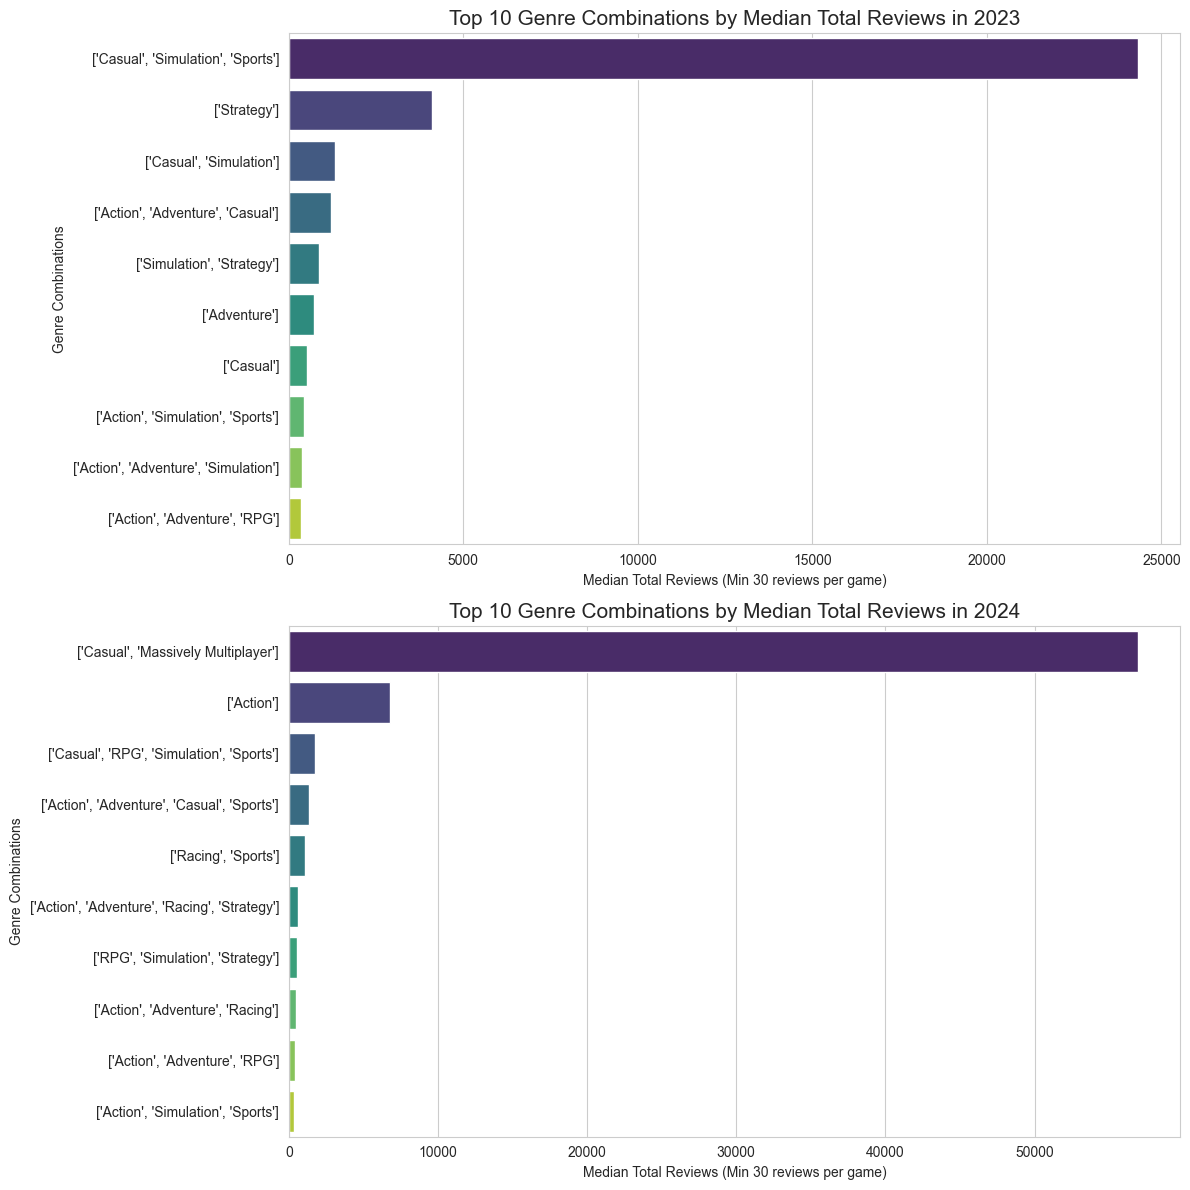

In [28]:
# 시각화 - 연도별로 그래프 칸 나누기
years = sorted(df_filtered['release_year'].unique().astype(int))
fig, axes = plt.subplots(len(years), 1, figsize=(12, 6 * len(years)))

sns.set_style("whitegrid")

for i, year in enumerate(years):
    # 해당 연도 데이터만 추출
    year_data = df_filtered[df_filtered['release_year'] == year]
    
    # 장르 조합별 중앙값 계산 후 상위 10개 추출
    top_genres = year_data.groupby('genre_no_indie')['total_reviews'].median().nlargest(10).reset_index()
    
    # 막대 그래프 그리기
    sns.barplot(data=top_genres, x='total_reviews', y='genre_no_indie', ax=axes[i], palette='viridis')
    
    axes[i].set_title(f'Top 10 Genre Combinations by Median Total Reviews in {year}', fontsize=15)
    axes[i].set_xlabel('Median Total Reviews (Min 30 reviews per game)')
    axes[i].set_ylabel('Genre Combinations')

plt.tight_layout()
plt.show()